This case study is the Capstone Project of **Google Data Analytics Professional Certificate** . In this case study I am working as a junior data analyst in the marketing analyst team at Cyclistic, a fictional bike-share company in Chicago.

Cyclistic is a bike-share program that features more than 5,800 bicycles and 600
docking stations. Cyclistic sets itself apart by also offering reclining bikes, hand
tricycles, and cargo bikes, making bike-share more inclusive to people with disabilities
and riders who can’t use a standard two-wheeled bike. The majority of riders opt for
traditional bikes; about 8% of riders use the assistive options. Cyclistic users are more
likely to ride for leisure, but about 30% use the bikes to commute to work each day.
Until now, Cyclistic’s marketing strategy relied on building general awareness and appealing to
broad consumer segments. One approach that helped make these things possible was the
flexibility of its pricing plans: single-ride passes, full-day passes, and annual memberships.
Customers who purchase single-ride or full-day passes are referred to as casual riders.
Customers who purchase annual memberships are Cyclistic members.

In 2016, Cyclistic launched a successful bike-share offering. Since then, the program has grown
to a fleet of 5,824 bicycles that are geotracked and locked into a network of 692 stations across
Chicago. The bikes can be unlocked from one station and returned to any other station in the
system anytime.
Cyclistic’s finance analysts have concluded that annual members are much more profitable
than casual riders. Although the pricing flexibility helps Cyclistic attract more customers,
Moreno believes that maximizing the number of annual members will be key to future growth.
Rather than creating a marketing campaign that targets all-new customers, Moreno believes
there is a solid opportunity to convert casual riders into members. She notes that casual riders
are already aware of the Cyclistic program and have chosen Cyclistic for their mobility needs.

Moreno has set a clear goal: Design marketing strategies aimed at converting casual riders into
annual members. In order to do that, however, the team needs to better understand 
**howannual members and casual riders differ, why casual riders would buy a membership, and howdigital media could affect their marketing tactics.**
 Moreno and her team are interested in
analyzing the Cyclistic historical bike trip data to identify trends.

# Ask
How do annual members and casual riders use Cyclistic bikes differently?

Why would casual riders buy Cyclistic annual memberships

How can Cyclistic use digital media to influence casual riders to become members?

The goal of this analysis is to identify usage patterns and provide recommendations to convert casual riders into annual members.

# **Prepare**
The dataset used for this analysis is the [Cyclistic bike-share trip data](https://divvy-tripdata.s3.amazonaws.com/index.html), which contains historical ride information.

The data was downloaded from the Cyclistic trip data repository and stored locally for analysis.

The dataset is organized in CSV format, with each row representing a single bike trip and each column representing trip attributes.

The data is structured data ie., Organised data.

The datasets have a different name because Cyclistic
is a fictional company. For the purposes of this case study, the datasets are appropriate and will
enable you to answer the business questions. 

The data has been made available by Motivate
International Inc. under this [license](http://divvybikes.com/data-license-agreement).

Data comes from the official Cyclistic trip records.
Data was collected directly from the bike-share system.
Contains detailed ride information such as time, station, and rider type.
Data represents recent bike-share activity.
Provided through the Cyclistic data repository.so its(**Reliable** ,**Original** ,**Comprehensive** ,**Curent** ,**Cited** )

**Limitation**

This is public data that we can use to explore how
different customer types are using Cyclistic bikes. But 
**data-privacy issues prohibit me from using riders’ personally identifiable information.**
 
This means that we won’t be able to

**connect pass purchases to credit card numbers to determine if casual riders live in the Cyclisticservice area or if they have purchased multiple single passes.**












# **Process**

Excel : Used for initial data exploration and cleaning, such as filtering rows, checking missing values, and creating new calculated columns like ride duration and day of week.

MySQL: Used for data analysis and aggregation. SQL queries were used to calculate metrics such as average ride duration and number of rides by day and month.

The dataset was checked to ensure that the data was accurate and consistent before analysis.

The following checks were performed:

* Verified that ride start times occur before ride end times
* Ensured ride duration values were valid
* Checked for duplicate ride IDs
* Reviewed missing or incomplete values

These steps helped maintain the integrity and reliability of the dataset.

Several cleaning steps were performed:

* Removed duplicate rows
* Removed rides with missing or null values
* Converted date columns to proper datetime format
* Calculated ride length from start and end time
* Created new variables such as day of week and month

Data cleanliness was verified by:

* Sorting and filtering data to identify anomalies
* Checking summary statistics for ride duration
* Ensuring there were no negative or unrealistic ride durations
* Confirming that all required columns were formatted correctly


REmove Empty filed by sorting start_station_name and remove empty fileds. sort data by end_station_name and remove empty fields.
Remove duplicates by using excel check with same ID
create a column name ride_length (started_at-ended_at) and format it with format as HH:MM:SS using Format > Cells > Time > 37:30:55.

created a column name day_of_week ,WEEKDAY command (for example, =WEEKDAY(C2,1)) in each file.
Format as General or as a number with no decimals, noting that 1 = Sunday and 7 =
Saturday.


# **Analyze**
The dataset was organized in a structured table format where each row represents a single bike ride and each column represents an attribute of the ride.

Created a pivot table to quickly calculate and visualize the data
Calculated the average ride_length for members and casual riders.rows =
member_casual; Values = Average of ride_length.

● Calculated the average ride_length for users by day_of_week.
columns = day_of_week; Rows = member_casual; Values = Average of ride_length.

● Calculated the number of rides for users by day_of_week by adding Count of
trip_id to Values

The 12 monthly CSV files were first uploaded and merged into one table using Google BigQuery. This combined dataset allowed easier analysis of all rides for the year.This gives me a new table **all_trips**




In [1]:
create or replace Table `casestudy-490304.trip_data.all_trips` AS 
SELECT * FROM `casestudy-490304.trip_data.202501` 
UNION ALL 
SELECT *  FROM `casestudy-490304.trip_data.202502`
UNION ALL
SELECT *  FROM `casestudy-490304.trip_data.202503`
UNION ALL 
SELECT *  FROM `casestudy-490304.trip_data.202504`
UNION ALL
SELECT *  FROM `casestudy-490304.trip_data.202505`; 

SyntaxError: invalid decimal literal (2539389243.py, line 1)

Explore your data,looking at the total number of rows, distinct values,
maximum, minimum, or mean values.

In [ ]:
SELECT count(*) FROM `casestudy-490304.trip_data.all_trips` 

In [ ]:
SELECT DISTINCT rideable_type FROM `casestudy-490304.trip_data.all_trips`;


In [ ]:
SELECT DISTINCT member_casual FROM `casestudy-490304.trip_data.all_trips`;

Sorted the data by day_of_week, start_time and their ride_count, grouped by member and casual riders:


In [ ]:
SELECT count(ride_id) as ride_count,day_of_week,member_casual ,EXTRACT(HOUR FROM started_at) as start_time
FROM `casestudy-490304.trip_data.all_trips` 
GROUP BY day_of_week,start_time,member_casual
ORDER BY day_of_week,start_time,member_casual

Result:

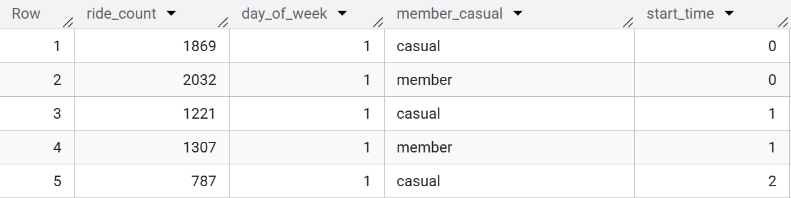

Amount of rides and ride duration per bike type for casual riders and members:


In [ ]:
SELECT count(ride_id) as total_ride ,rideable_type,member_casual,
AVG(TIMESTAMP_DIFF(ended_at, started_at, MINUTE)) AS avg_ride_length_minutes 
FROM `casestudy-490304.trip_data.all_trips` 
GROUP BY rideable_type,member_casual
ORDER BY member_casual,total_ride DESC;

Result:

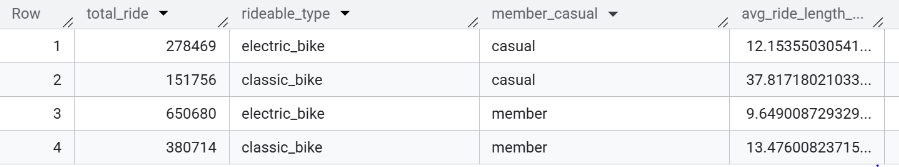

See the average ride time by each day for members vs casual users

In [ ]:
SELECT
member_casual,
AVG(TIMESTAMP_DIFF(ended_at, started_at, MINUTE)) AS ride_length_minutes
FROM `casestudy-490304.trip_data.all_trips`
GROUP BY member_casual;

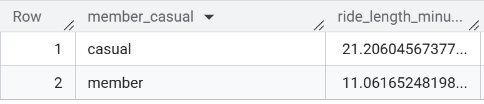

Now checking average ride time by each day for member type

Group data by member type and day of week

Calculate average ride length

In [ ]:
SELECT
member_casual,
day_of_week,
AVG(TIMESTAMP_DIFF(ended_at, started_at, MINUTE)) AS avg_ride_length_minutes
FROM casestudy-490304.trip_data.all_trips
WHERE ended_at > started_at
GROUP BY member_casual, day_of_week
ORDER BY member_casual, day_of_week;

Result:

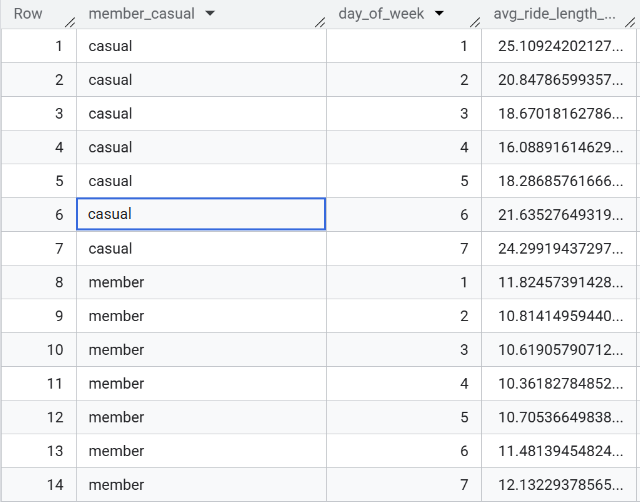

**The number of rides significantly increases during weekends for casual riders.**

changing number into weekdays for easy analysis.
Order the days of the week for correct sorting for analysis.

In [ ]:
SELECT
member_casual,
FORMAT_TIMESTAMP('%A', started_at) AS day_of_week,
AVG(TIMESTAMP_DIFF(ended_at, started_at, MINUTE)) AS avg_ride_length
FROM `casestudy-490304.trip_data.all_trips`
GROUP BY member_casual, day_of_week
ORDER BY
CASE day_of_week
WHEN 'Sunday' THEN 1
WHEN 'Monday' THEN 2
WHEN 'Tuesday' THEN 3
WHEN 'Wednesday' THEN 4
WHEN 'Thursday' THEN 5
WHEN 'Friday' THEN 6
WHEN 'Saturday' THEN 7
END;


RESULT: 


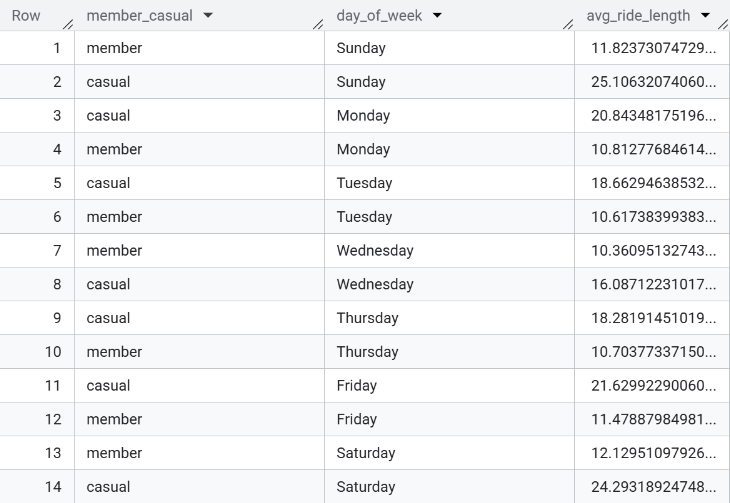

Casual riders ride longer on weekends

Members ride more during weekdays

Summary of rides and duration by rider type and weekday

In [ ]:
SELECT
member_casual,
day_of_week,
COUNT(ride_id) AS number_of_rides,
AVG(TIMESTAMP_DIFF(ended_at, started_at, MINUTE)) AS average_duration
FROM `casestudy-490304.trip_data.all_trips`
WHERE ended_at > started_at
GROUP BY member_casual, day_of_week;

Result: 

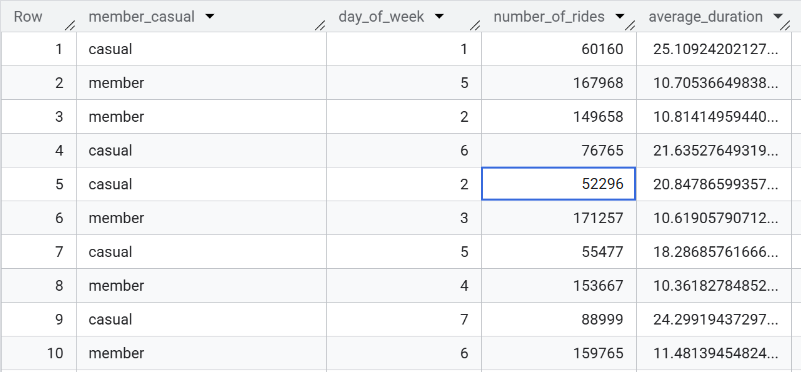


# *Share*

For the visualisations, I have imported my data in Tableau. This was done by exporting the tables created by running the SQL queries in the Analyse phase, then converting the files to an .xlsx format and finally importing the data source into Tableau.

The visualizations included comparisons of ride frequency by day of the week, average ride duration, and overall usage trends. These charts revealed that casual riders tend to take longer rides and are more active on weekends, while annual members ride more frequently during weekdays, suggesting commuting behavior. By organizing the data visually, it became easier to identify and communicate these behavioral patterns.

The intended audience for this analysis includes Cyclistic’s marketing team and business stakeholders, who require concise and actionable insights rather than technical details. Therefore, the dashboard was designed to be simple, intuitive, and focused on key findings. Clear titles, labels, and consistent color schemes were used to ensure accessibility and readability.

Overall, the use of data visualization helped transform raw data into meaningful insights, enabling stakeholders to quickly understand user behavior and make informed, data-driven decisions.

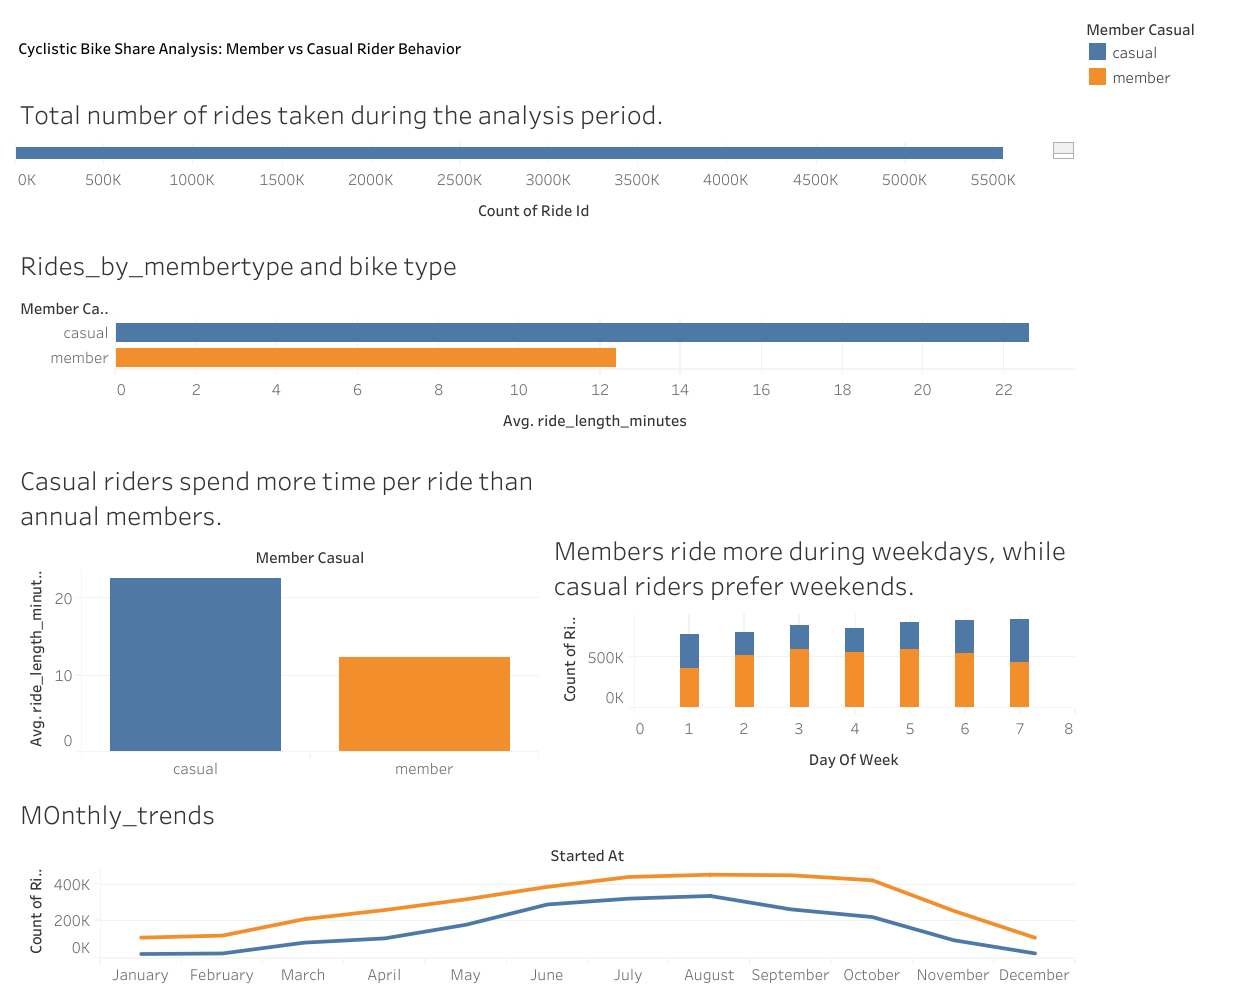




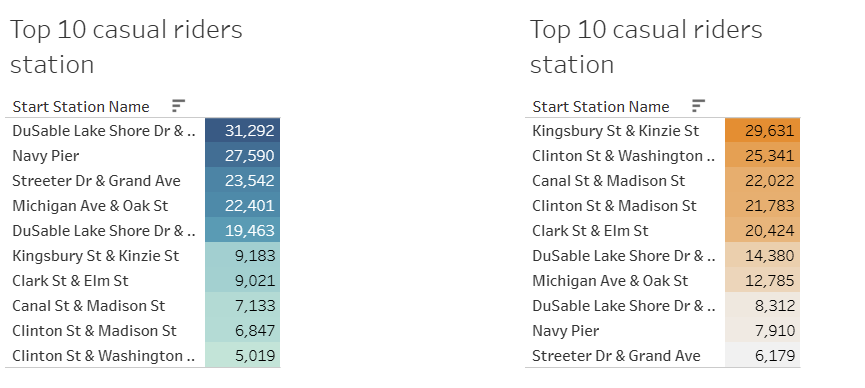

[View Visual on tableau](https://public.tableau.com/app/profile/amruta.shah6527/viz/CyclisticCaseStudy_17745422689920/CyclisticBikeShareAnalysis#1)
# **Act** 

Based on the analysis, casual riders and annual members use Cyclistic bikes differently.

Casual riders take longer rides and mostly ride on weekends, indicating leisure use.
Annual members take shorter, frequent rides during weekdays, suggesting commuting behavior.

This shows that casual riders are more likely using the service for recreation, while members rely on it for daily transportation.

Cyclistic can use these insights to convert casual riders into annual members by targeting their behavior:

Offer weekend promotions or discounts for casual riders

Introduce membership trials or short-term passes

Highlight cost savings of membership for frequent riders

Use targeted marketing campaigns focused on leisure riders
 
Recommended Next Steps based on our findings
Launch marketing campaigns focused on casual riders
Provide in app notifications or email offers during weekends
Analyze conversion rates after campaigns
Improve bike availability in high demand recreational areas

Additional data I could use to expand on my findings are
coustomers age,income or location 
weather data to understand right pattern
marketing campaign data to measure affectiveness



